In [9]:
import gym
from gym import spaces
import pygame
import numpy as np
import math
import matplotlib.pyplot as plt

# Задание 1. «Реализация среды» 
1. Используйте библиотеку для создания игровой среды, например, PyGame или gym (с кастомной средой)
2. Создайте простую двумерную карту с препятствиями (стены, блоки) и целью
3. Танк и цель должны быть представлены как объекты с координатами и углом поворота

In [10]:
class TankEnv(gym.Env):
    metadata = {'render.modes': ['human']}

    def __init__(self, grid_size=10, tank_speed=1, bullet_speed=3):
        super(TankEnv, self).__init__()
        self.grid_size = grid_size
        self.tank_speed = tank_speed
        self.bullet_speed = bullet_speed

        self.action_space = spaces.Discrete(5)
        self.observation_space = spaces.Box(low=0, high=1, shape=(9,), dtype=np.float32)

        pygame.init()
        self.screen = pygame.display.set_mode((400, 400))
        self.clock = pygame.time.Clock()

        self.tank = {'x': 0, 'y': 0, 'angle': 0}
        self.target = {'x': 7, 'y': 7}
        self.obstacles = [(5,5), (5,6), (6,5), (6,6), (2,2), (2,3), (3,2)]
        self.bullet = None

    def _get_state(self):
        return np.array([
            self.tank['x'] / self.grid_size,
            self.tank['y'] / self.grid_size,
            self.tank['angle'] / 360,
            self._distance_to_target() / (self.grid_size * math.sqrt(2)),
            (self._angle_to_target() + 180) / 360,
            self._obstacle_distance('forward'),
            self._obstacle_distance('backward'),
            self._obstacle_distance('left'),
            self._obstacle_distance('right')
        ], dtype=np.float32)

    def _distance_to_target(self):
        return math.hypot(self.target['x'] - self.tank['x'], 
                         self.target['y'] - self.tank['y'])

    def _angle_to_target(self):
        dx = self.target['x'] - self.tank['x']
        dy = self.target['y'] - self.tank['y']
        return math.degrees(math.atan2(dy, dx)) - self.tank['angle']

    def _obstacle_distance(self, direction):
        x, y = self.tank['x'], self.tank['y']
        angle_map = {
            'forward': self.tank['angle'],
            'backward': self.tank['angle'] + 180,
            'left': self.tank['angle'] - 90,
            'right': self.tank['angle'] + 90
        }
        angle = math.radians(angle_map[direction] % 360)
        dx, dy = math.cos(angle), math.sin(angle)
        
        for step in range(1, self.grid_size):
            check_x = x + dx * step
            check_y = y + dy * step
            if (int(check_x), int(check_y)) in self.obstacles:
                return step / self.grid_size
        return 1.0

    def step(self, action):
        reward = 0
        done = False
        prev_distance = self._distance_to_target()

        if action == 0:  # Forward
            dx = math.cos(math.radians(self.tank['angle'])) * self.tank_speed
            dy = math.sin(math.radians(self.tank['angle'])) * self.tank_speed
            new_x = self.tank['x'] + dx
            new_y = self.tank['y'] + dy
        elif action == 1:  # Backward
            dx = math.cos(math.radians(self.tank['angle'])) * self.tank_speed
            dy = math.sin(math.radians(self.tank['angle'])) * self.tank_speed
            new_x = self.tank['x'] - dx
            new_y = self.tank['y'] - dy
        elif action == 2:  # Left
            self.tank['angle'] = (self.tank['angle'] - 10) % 360
            new_x, new_y = self.tank['x'], self.tank['y']
        elif action == 3:  # Right
            self.tank['angle'] = (self.tank['angle'] + 10) % 360
            new_x, new_y = self.tank['x'], self.tank['y']
        elif action == 4 and self.bullet is None:  # Shoot
            self.bullet = {
                'x': self.tank['x'],
                'y': self.tank['y'],
                'dx': math.cos(math.radians(self.tank['angle'])) * self.bullet_speed,
                'dy': math.sin(math.radians(self.tank['angle'])) * self.bullet_speed
            }
            new_x, new_y = self.tank['x'], self.tank['y']
        else:
            new_x, new_y = self.tank['x'], self.tank['y']

        if action in [0, 1]:
            if (0 <= new_x < self.grid_size and 0 <= new_y < self.grid_size and
                (int(new_x), int(new_y)) not in self.obstacles):
                self.tank['x'] = new_x
                self.tank['y'] = new_y
            else:
                reward -= 10
                done = True

        if self.bullet is not None:
            self.bullet['x'] += self.bullet['dx']
            self.bullet['y'] += self.bullet['dy']
            bx, by = int(self.bullet['x']), int(self.bullet['y'])
            if (bx, by) == (int(self.target['x']), int(self.target['y'])):
                reward += 100
                done = True
                self.bullet = None
                return self._get_state(), reward, done, {}
            elif (bx < 0 or bx >= self.grid_size or by < 0 or by >= self.grid_size or
                  (bx, by) in self.obstacles):
                self.bullet = None

        new_distance = self._distance_to_target()
        reward += 10 if new_distance < prev_distance else -5
        reward -= 1

        if math.hypot(self.tank['x'] - self.target['x'], 
                     self.tank['y'] - self.target['y']) < 1:
            reward += 100
            done = True

        return self._get_state(), reward, done, {}

    def reset(self):
        self.tank = {
            'x': np.random.randint(0, self.grid_size),
            'y': np.random.randint(0, self.grid_size),
            'angle': np.random.randint(0, 360)
        }
        while True:
            self.target['x'], self.target['y'] = (
                np.random.randint(0, self.grid_size),
                np.random.randint(0, self.grid_size))
            if (self.target['x'], self.target['y']) not in self.obstacles and (
                self.target['x'], self.target['y']) != (self.tank['x'], self.tank['y']):
                break
        self.bullet = None
        return self._get_state()

    def render(self, mode='human'):
        self.screen.fill((255, 255, 255))
        cell_size = 400 // self.grid_size

        for obs in self.obstacles:
            pygame.draw.rect(self.screen, (0,0,0), 
                            (obs[0]*cell_size, obs[1]*cell_size, cell_size, cell_size))

        pygame.draw.circle(self.screen, (0,255,0), 
                          (int(self.target['x']*cell_size + cell_size/2),
                           int(self.target['y']*cell_size + cell_size/2)), 
                          cell_size//3)

        tank_surf = pygame.Surface((cell_size, cell_size), pygame.SRCALPHA)
        pygame.draw.rect(tank_surf, (0,0,255), (10, 10, 20, 20))
        rotated = pygame.transform.rotate(tank_surf, -self.tank['angle'])
        rect = rotated.get_rect(center=(self.tank['x']*cell_size + cell_size/2,
                                      self.tank['y']*cell_size + cell_size/2))
        self.screen.blit(rotated, rect)

        if self.bullet:
            pygame.draw.circle(self.screen, (255,0,0), 
                              (int(self.bullet['x']*cell_size),
                               int(self.bullet['y']*cell_size)), 5)

        pygame.display.flip()
        self.clock.tick(30)

    def close(self):
        pygame.quit()

# Задание 2. «Определение системы» 
Определение состояния, действий и награды (пример):
1. Состояние (State):
    1. Положение танка (x, y)
    2. Угол поворота танка
    3. Расстояние до цели
    4. Угол до цели относительно танка
    5. Наличие препятствий вблизи (например, расстояние до ближайшего препятствия в четырёх направлениях)
2. Действия (Action):
    1. Движение вперёд
    2. Движение назад
    3. Поворот влево
    4. Поворот вправо
    5. Стрельба
3. Награда (Reward):
    1. +100 за попадание в цель
    2. -10 за столкновение с препятствием. -1 за каждый шаг (штраф за время)
    3. -1 за каждый шаг (штраф за время)
    4. +10 за приближение к цели
    5. -5 за удаление от цели

Система наград включена в настройку окружения

# Задание 3. «Реализация агента» 
1. Используйте алгоритм обучения с подкреплением, например, Q-learning, Deep Q Network (DQN) или Policy Gradient
2. Реализуйте функцию выбора действия на основе текущей политики (например, ε жадная стратегия для Q-learning)
3. Обучите агента в среде, сохраняя результаты обучения (награды за эпизоды)

In [11]:
class QLearningAgent:
    def __init__(self, actions, alpha=0.1, gamma=0.99, epsilon=0.1):
        self.actions = actions
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.q_table = {}

    def discretize(self, state):
        return (
            int(state[0] * 5),
            int(state[1] * 5),
            int(state[2] * 8) % 8,
            min(int(state[3] * 5), 4),
            int((state[4] * 8) % 8),
            *(int(s > 0.2) for s in state[5:9])
        )

    def get_action(self, state):
        d_state = self.discretize(state)
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.actions)
        q_vals = [self.q_table.get((d_state, a), 0) for a in self.actions]
        return self.actions[np.argmax(q_vals)]

    def update(self, state, action, reward, next_state, done):
        d_state = self.discretize(state)
        d_next = self.discretize(next_state)
        
        current_q = self.q_table.get((d_state, action), 0)
        max_next_q = max([self.q_table.get((d_next, a), 0) for a in self.actions]) if not done else 0
        
        new_q = current_q + self.alpha * (reward + self.gamma * max_next_q - current_q)
        self.q_table[(d_state, action)] = new_q

# Задание 4. «Тестирование и анализ» 
1. Протестируйте обученного агента в среде
2. Визуализируйте процесс обучения (график накопленной награды за эпизоды)
3. Проверьте, как агент справляется с изменением начальных условий (разные стартовые позиции танка и цели)

Episode: 0, Reward: -208, Epsilon: 0.99
Episode: 50, Reward: -349, Epsilon: 0.77
Episode: 100, Reward: -28, Epsilon: 0.60
Episode: 150, Reward: 29, Epsilon: 0.47
Episode: 200, Reward: -46, Epsilon: 0.37
Episode: 250, Reward: -16, Epsilon: 0.28
Episode: 300, Reward: -7, Epsilon: 0.22
Episode: 350, Reward: 26, Epsilon: 0.17
Episode: 400, Reward: -28, Epsilon: 0.13
Episode: 450, Reward: 157, Epsilon: 0.10
Episode: 500, Reward: -19, Epsilon: 0.08
Episode: 550, Reward: 2, Epsilon: 0.06
Episode: 600, Reward: -16, Epsilon: 0.05
Episode: 650, Reward: 112, Epsilon: 0.04
Episode: 700, Reward: 127, Epsilon: 0.03
Episode: 750, Reward: 11, Epsilon: 0.02
Episode: 800, Reward: -28, Epsilon: 0.02
Episode: 850, Reward: 112, Epsilon: 0.01
Episode: 900, Reward: -22, Epsilon: 0.01
Episode: 950, Reward: 541, Epsilon: 0.01
Episode: 1000, Reward: -16, Epsilon: 0.01
Episode: 1050, Reward: 20, Epsilon: 0.01
Episode: 1100, Reward: 125, Epsilon: 0.01
Episode: 1150, Reward: 14, Epsilon: 0.01
Episode: 1200, Reward

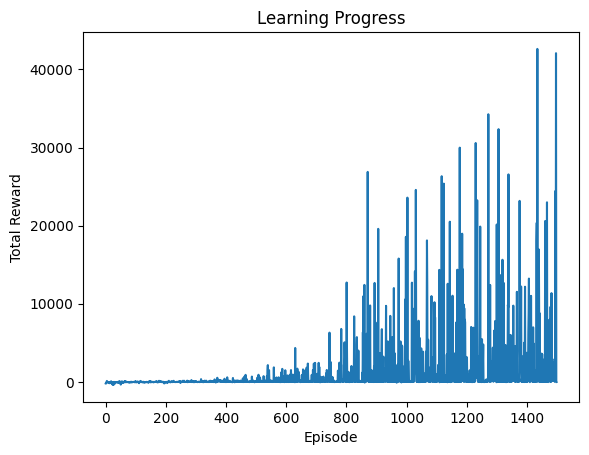

In [12]:
env = TankEnv()
agent = QLearningAgent(actions=list(range(5)), alpha=0.1, gamma=0.95, epsilon=1.0)

rewards = []
episodes = 1_500

for episode in range(episodes):
    state = env.reset()
    total_reward = 0
    done = False
    
    while not done:
        action = agent.get_action(state)
        next_state, reward, done, _ = env.step(action)
        agent.update(state, action, reward, next_state, done)
        state = next_state
        total_reward += reward
        
    rewards.append(total_reward)
    agent.epsilon = max(0.01, agent.epsilon * 0.995)
    
    if episode % 50 == 0:
        print(f"Episode: {episode}, Reward: {total_reward}, Epsilon: {agent.epsilon:.2f}")

plt.plot(rewards)
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Learning Progress')
plt.show()

In [14]:
for _ in range(100):
    state = env.reset()
    done = False
    while not done:
        action = agent.get_action(state)
        state, _, done, _ = env.step(action)
        env.render()
env.close()

KeyboardInterrupt: 

In [15]:
pygame.quit()